# MediStat: Hospital Patient Analytics
**The premise:** You are a data analyst hired by a mid-sized hospital network. They have collected patient records over several years and need you to analyze operational efficiency, patient risk patterns, and resource utilization, and present your findings in a clean, documented report.

## Phase 1: Project Setup & Data Acquisition

In [1]:
"""
=============================================================
MediStat — Hospital Patient Analytics
=============================================================
Author      : Proshanta Pal
Dataset     : Healthcare Dataset (Kaggle)
Last Updated: 2026-03-10

Objective:
    Analyze patient records from a multi-hospital network to uncover
    patterns in admissions, billing, medical conditions, and length
    of stay, supporting data-driven operational decisions.

Questions:
    1. Age & condition distribution across the patient population
    2. Prevalence and demographic clustering of medical conditions
    3. Drivers of longer hospital stays
    4. Billing patterns across insurance providers
    5. Hospital and doctor workload analysis
=============================================================
"""

# Standard Library
import warnings
import os

# Data Manipulation
import numpy as np
import pandas as pd

# Data Visualization 
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# Display & Style Configuration 
warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:.2f}".format)
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)

# Ensure output directories exist 
os.makedirs("../data/processed", exist_ok=True)
os.makedirs("../outputs/figures", exist_ok=True)
os.makedirs("../outputs/reports", exist_ok=True)

print("Environment ready. All libraries loaded successfully.")

Environment ready. All libraries loaded successfully.


## Phase 2: Loading Data & First Look

In [2]:
# Loading Data
DATA_PATH = "../data/raw/healthcare_dataset.csv"
df = pd.read_csv(DATA_PATH)
print(f"Dataset loaded. Shape: {df.shape}")

Dataset loaded. Shape: (55500, 15)


After loading the data, observe the dataset first.

In [3]:
# Shape and Column
print(f"Rows   : {df.shape[0]:,}")
print(f"Columns: {df.shape[1]}")
print(f"Column Names:\n{df.columns.tolist()}")

Rows   : 55,500
Columns: 15
Column Names:
['Name', 'Age', 'Gender', 'Blood Type', 'Medical Condition', 'Date of Admission', 'Doctor', 'Hospital', 'Insurance Provider', 'Billing Amount', 'Room Number', 'Admission Type', 'Discharge Date', 'Medication', 'Test Results']


In [4]:
# First glance at the data
df.head()

,Name,Age,Gender,Blood Type,Medical Condition,Date of Admission,Doctor,Hospital,Insurance Provider,Billing Amount,Room Number,Admission Type,Discharge Date,Medication,Test Results
0,Bobby JacksOn,30,Male,B-,Cancer,2024-01-31,Matthew Smith,Sons and Miller,Blue Cross,18856.28,328,Urgent,2024-02-02,Paracetamol,Normal
1,LesLie TErRy,62,Male,A+,Obesity,2019-08-20,Samantha Davies,Kim Inc,Medicare,33643.33,265,Emergency,2019-08-26,Ibuprofen,Inconclusive
2,DaNnY sMitH,76,Female,A-,Obesity,2022-09-22,Tiffany Mitchell,Cook PLC,Aetna,27955.10,205,Emergency,2022-10-07,Aspirin,Normal
3,andrEw waTtS,28,Female,O+,Diabetes,2020-11-18,Kevin Wells,"Hernandez Rogers and Vang,",Medicare,37909.78,450,Elective,2020-12-18,Ibuprofen,Abnormal
4,adrIENNE bEll,43,Female,AB+,Cancer,2022-09-19,Kathleen Hanna,White-White,Aetna,14238.32,458,Urgent,2022-10-09,Penicillin,Abnormal


In [5]:
# Data Types and Memory
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 55500 entries, 0 to 55499
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Name                55500 non-null  object 
 1   Age                 55500 non-null  int64  
 2   Gender              55500 non-null  object 
 3   Blood Type          55500 non-null  object 
 4   Medical Condition   55500 non-null  object 
 5   Date of Admission   55500 non-null  object 
 6   Doctor              55500 non-null  object 
 7   Hospital            55500 non-null  object 
 8   Insurance Provider  55500 non-null  object 
 9   Billing Amount      55500 non-null  float64
 10  Room Number         55500 non-null  int64  
 11  Admission Type      55500 non-null  object 
 12  Discharge Date      55500 non-null  object 
 13  Medication          55500 non-null  object 
 14  Test Results        55500 non-null  object 
dtypes: float64(1), int64(2), object(12)
memory usage: 6.4

In [6]:
# Statistical Summary
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Name,55500,49992,DAvId muNoZ,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Age,55500.00,NaN,NaN,NaN,51.54,19.60,13.00,35.00,52.00,68.00,89.00
Gender,55500,2,Male,27774,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Blood Type,55500,8,A-,6969,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Medical Condition,55500,6,Arthritis,9308,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Date of Admission,55500,1827,2024-03-16,50,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Doctor,55500,40341,Michael Smith,27,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Hospital,55500,39876,LLC Smith,44,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Insurance Provider,55500,5,Cigna,11249,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Billing Amount,55500.00,NaN,NaN,NaN,25539.32,14211.45,-2008.49,13241.22,25538.07,37820.51,52764.28


In [7]:
# Check Missing Value exist or not
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)

missing_report = pd.DataFrame({
    'Missing': missing,
    'Missing (%)': missing_pct
}).sort_values("Missing (%)", ascending=False)

print(missing_report[missing_report["Missing"] > 0])
missing_report

Empty DataFrame
Columns: [Missing, Missing (%)]
Index: []


,Missing,Missing (%)
Name,0,0.00
Age,0,0.00
Gender,0,0.00
Blood Type,0,0.00
Medical Condition,0,0.00
Date of Admission,0,0.00
Doctor,0,0.00
Hospital,0,0.00
Insurance Provider,0,0.00
Billing Amount,0,0.00


In [8]:
# Calculate how many days a patient was admitted
pd.to_datetime(df["Discharge Date"])- pd.to_datetime(df["Date of Admission"])

0        2 days
1        6 days
2       15 days
3       30 days
4       20 days
          ...  
55495   30 days
55496    9 days
55497   28 days
55498    6 days
55499   27 days
Length: 55500, dtype: timedelta64[ns]

## Phase 3: Data Cleaning and Validation

In [9]:
# Standardize column names
df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_")

# Convert date columns to datetime
df['date_of_admission'] = pd.to_datetime(df['date_of_admission'])
df['discharge_date'] = pd.to_datetime(df['discharge_date'])

# Length of staying a patient in hospital
df['len_of_stay'] = (df['discharge_date'] - df['date_of_admission']).dt.days

# Standardize text columns
df['gender'] = df['gender'].str.strip().str.title()
df['blood_type'] = df['blood_type'].str.strip().str.upper()

# Save Processed Data
df.to_csv('../data/processed/healthcare_cleaned.csv', index=False)

print("Date Cleaning Successfully.")
print(df[["date_of_admission", "discharge_date", "len_of_stay"]].head())

Date Cleaning Successfully.
  date_of_admission discharge_date  len_of_stay
0        2024-01-31     2024-02-02            2
1        2019-08-20     2019-08-26            6
2        2022-09-22     2022-10-07           15
3        2020-11-18     2020-12-18           30
4        2022-09-19     2022-10-09           20


## Phase 4: Exploratory Data Analysis (EDA)

In [10]:
# Age Distribution Analysis 
age_stats = df["age"].agg(
    Min    = "min",
    Max    = "max",
    Mean   = "mean",
    Median = "median",
    Std    = "std"
).round(2)

print(age_stats)

Min      13.00
Max      89.00
Mean     51.54
Median   52.00
Std      19.60
Name: age, dtype: float64


In [11]:
# Age by Gender 
print(df.groupby("gender")["age"].agg(["mean", "median", "std"]).round(2))

        mean  median   std
gender                    
Female 51.58   52.00 19.67
Male   51.50   52.00 19.53


In [12]:
# Patient Segments by Age
bins   = [0, 18, 35, 50, 65, 100]
labels = ["<18", "18-35", "36-50", "51-65", "65+"]

df["age_group"] = pd.cut(df["age"], bins=bins, labels=labels)

print(df["age_group"].value_counts().sort_index())

age_group
<18        888
18-35    13644
36-50    12301
51-65    12417
65+      16250
Name: count, dtype: int64


In [13]:
# Medical Condition Frequency
df['medical_condition'].value_counts()

medical_condition
Arthritis       9308
Diabetes        9304
Hypertension    9245
Obesity         9231
Cancer          9227
Asthma          9185
Name: count, dtype: int64

In [14]:
# Condition by Gender
df.groupby(['medical_condition', 'gender'])['age'].count().unstack()

gender,Female,Male
medical_condition,,
Arthritis,4686,4622
Asthma,4553,4632
Cancer,4602,4625
Diabetes,4651,4653
Hypertension,4612,4633
Obesity,4622,4609


In [15]:
# Condition vs Age and Length of Stay
condition_states = df.groupby('medical_condition').agg(
    total_patient = ('age', 'count'),
    avg_patient_age = ('age', 'mean'),
    avg_len_of_stay = ('len_of_stay', 'mean'),
    avg_billing = ('billing_amount', 'mean')
).sort_values('avg_len_of_stay', ascending=False)

condition_states

,total_patient,avg_patient_age,avg_len_of_stay,avg_billing
medical_condition,,,,
Asthma,9185,51.58,15.70,25635.25
Arthritis,9308,51.57,15.52,25497.33
Cancer,9227,51.56,15.50,25161.79
Obesity,9231,51.24,15.46,25805.97
Hypertension,9245,51.74,15.46,25497.10
Diabetes,9304,51.55,15.42,25638.41


In [16]:
# Condition by Admission Type
admission_condition = df.groupby(['medical_condition', 'admission_type'])['len_of_stay'].mean().unstack()
admission_condition

admission_type,Elective,Emergency,Urgent
medical_condition,,,
Arthritis,15.63,15.51,15.41
Asthma,15.74,15.58,15.77
Cancer,15.26,15.99,15.25
Diabetes,15.61,15.59,15.09
Hypertension,15.47,15.39,15.51
Obesity,15.44,15.52,15.44


In [17]:
# Billing by Insurance Provider
billing_insurance = df.groupby('insurance_provider').agg(
    patient_count = ('billing_amount', 'count'),
    avg_billing = ('billing_amount', 'mean'),
    median_billing = ('billing_amount', 'median'),
    std_billing = ('billing_amount', 'std')
).round(2).sort_values('avg_billing', ascending=False)

billing_insurance

,patient_count,avg_billing,median_billing,std_billing
insurance_provider,,,,
Medicare,11154,25615.99,25592.81,14142.48
Blue Cross,11059,25613.01,25594.70,14113.62
Aetna,10913,25553.29,25786.39,14269.23
Cigna,11249,25525.77,25545.20,14241.21
UnitedHealthcare,11125,25389.17,25185.49,14291.57


In [18]:
# Billing by Admission Type
billing_admission = df.groupby('admission_type').agg(
    avg_billing = ('billing_amount', 'mean'),
    median_billing = ('billing_amount', 'median')
).round(2).sort_values('avg_billing', ascending=False)

billing_admission

,avg_billing,median_billing
admission_type,,
Elective,25602.23,25656.93
Urgent,25517.36,25550.37
Emergency,25497.40,25379.57


In [19]:
# Billing by Medical Condition and Admission Type
billing = df.groupby(['medical_condition', 'admission_type'])['billing_amount'].mean().unstack()
billing

admission_type,Elective,Emergency,Urgent
medical_condition,,,
Arthritis,25441.76,25515.03,25534.64
Asthma,25241.32,25878.32,25795.03
Cancer,25698.60,24862.49,24904.79
Diabetes,25983.14,25482.63,25457.48
Hypertension,25577.05,25420.37,25488.07
Obesity,25676.87,25814.62,25925.44


In [20]:
# Billing Percentiles
percentiles = np.percentile(df['billing_amount'], [25, 50, 75, 90, 95, 99])
labels = ['25th', '50th', '75th', '90th', '95th', '99th']

for label, val in zip(labels, percentiles):
    print(f"{label} percentile: ${val:,.2f}")

25th percentile: $13,241.22
50th percentile: $25,538.07
75th percentile: $37,820.51
90th percentile: $45,162.99
95th percentile: $47,637.25
99th percentile: $49,848.12


## Phase 5: Data Visualization   

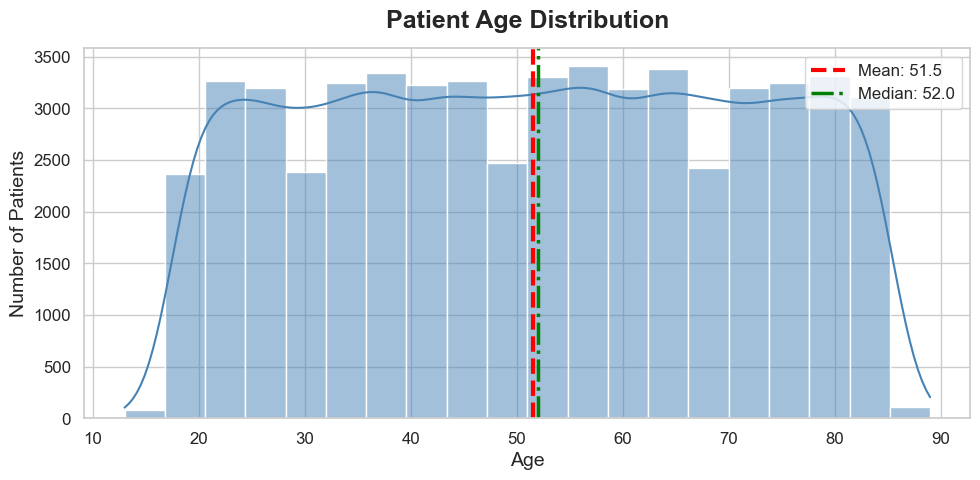

In [21]:
# Age Distribution of patients
fig, ax = plt.subplots(figsize=(10, 5))

sns.histplot(
    data = df,
    x = 'age',
    bins = 20,
    kde = True,
    color = 'steelblue'
)

ax.set_title("Patient Age Distribution", fontsize=18, fontweight='bold', pad=15)
ax.set_xlabel("Age", fontsize=14)
ax.set_ylabel("Number of Patients", fontsize=14)
ax.axvline(df['age'].mean(), color='red', linestyle='--', lw=3, label=f"Mean: {df['age'].mean():.1f}")
ax.axvline(df['age'].median(), color='green', ls='-.', lw=2.5, label=f"Median: {df['age'].median():.1f}")
ax.legend(loc='upper right')

plt.tight_layout()
plt.savefig("../outputs/figures/01_age_distribution.png", dpi=150, bbox_inches='tight')
plt.show()

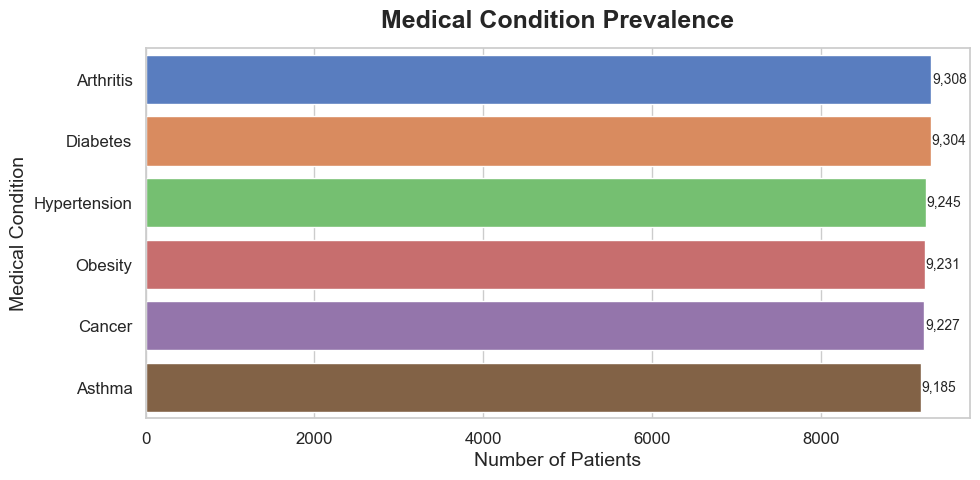

In [22]:
# Medical Condition Prevalence
condition_counts = df['medical_condition'].value_counts()

fig, ax = plt.subplots(figsize=(10, 5))

sns.barplot(
    x = condition_counts.values,
    y = condition_counts.index,
    palette='muted',
    ax = ax
)

ax.set_title("Medical Condition Prevalence", fontsize=18, fontweight='bold', pad=15)
ax.set_xlabel("Number of Patients", fontsize=14)
ax.set_ylabel("Medical Condition", fontsize=14)

for i, v in enumerate(condition_counts.values):
    ax.text(v + 10, i, f"{v:,}", va="center", fontsize=10)

plt.tight_layout()
plt.savefig("../outputs/figures/02_condition_prevalence.png", dpi=150, bbox_inches="tight")
plt.show()

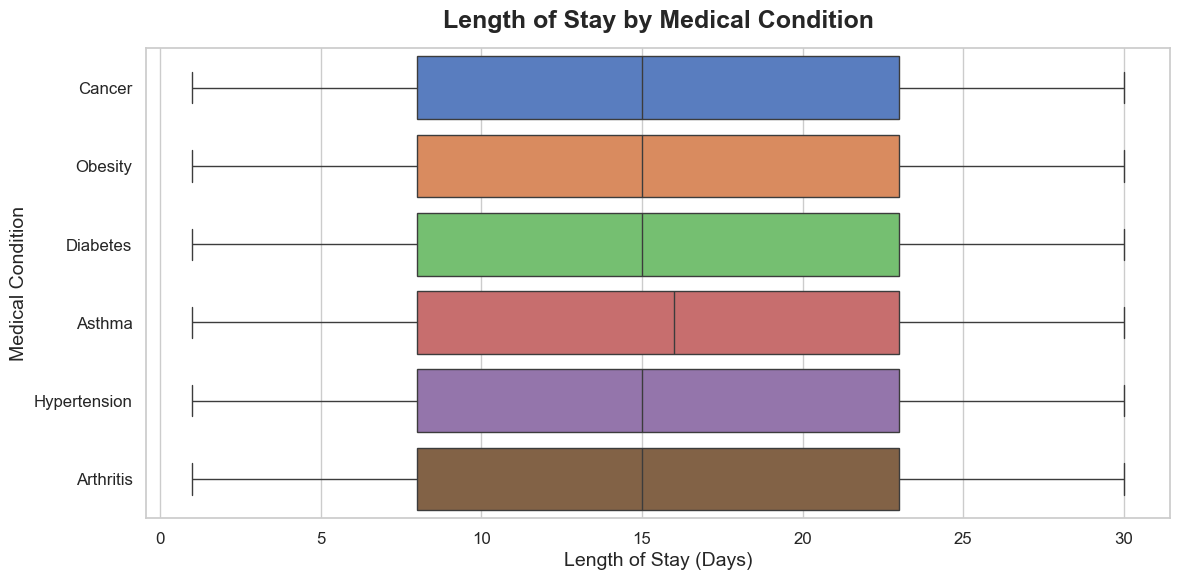

In [23]:
# Length of Stay by Condition
fig, ax = plt.subplots(figsize=(12, 6))

sns.boxplot(
    data    = df,
    x       = "len_of_stay",
    y       = "medical_condition",
    palette = "muted",
    ax      = ax
)

ax.set_title("Length of Stay by Medical Condition", fontsize=18, fontweight="bold", pad=15)
ax.set_xlabel("Length of Stay (Days)", fontsize=14)
ax.set_ylabel("Medical Condition", fontsize=14)

plt.tight_layout()
plt.savefig("../outputs/figures/03_len_of_stay.png", dpi=150, bbox_inches="tight")
plt.show()

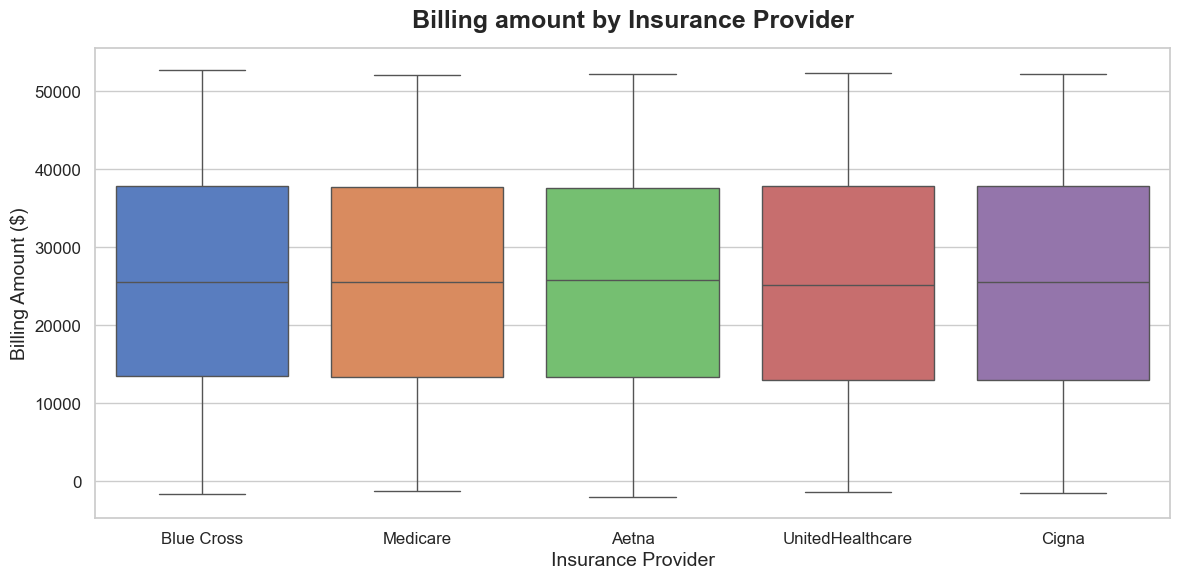

In [24]:
# Billing by Insurance Provider
fig, ax = plt.subplots(figsize=(12, 6))

sns.boxplot(
    data = df,
    x = "insurance_provider",
    y = "billing_amount",
    palette = "muted",
    ax = ax
)

ax.set_title("Billing amount by Insurance Provider", fontsize=18, fontweight="bold", pad=15)
ax.set_xlabel("Insurance Provider", fontsize=14)
ax.set_ylabel("Billing Amount ($)", fontsize=14)

plt.tight_layout()
plt.savefig("../outputs/figures/04_billing_insurance.png", dpi=150, bbox_inches="tight")
plt.show()

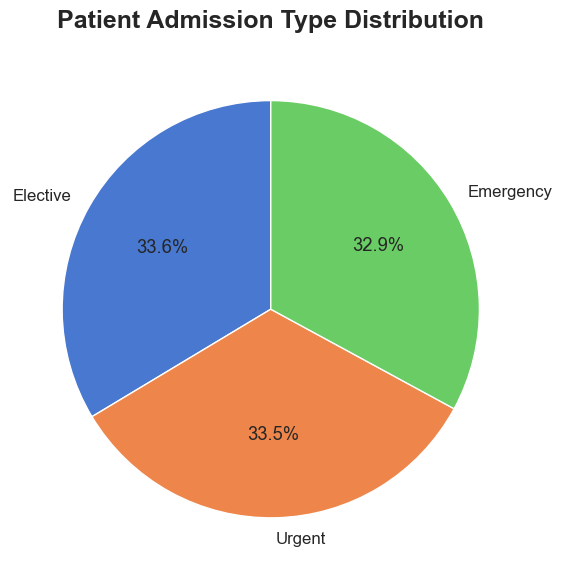

In [25]:
# Admission Type Distribution
admission_counts = df["admission_type"].value_counts()

fix, ax = plt.subplots(figsize=(12, 6))

wedges, texts, autotexts = ax.pie(
    admission_counts.values,
    labels = admission_counts.index,
    autopct = "%1.1f%%",
    startangle = 90
)

ax.set_title("Patient Admission Type Distribution", fontsize=18, fontweight="bold", pad=15)

plt.tight_layout()
plt.savefig("../outputs/figures/05_admission_type.png", dpi=150, bbox_inches="tight")
plt.show()

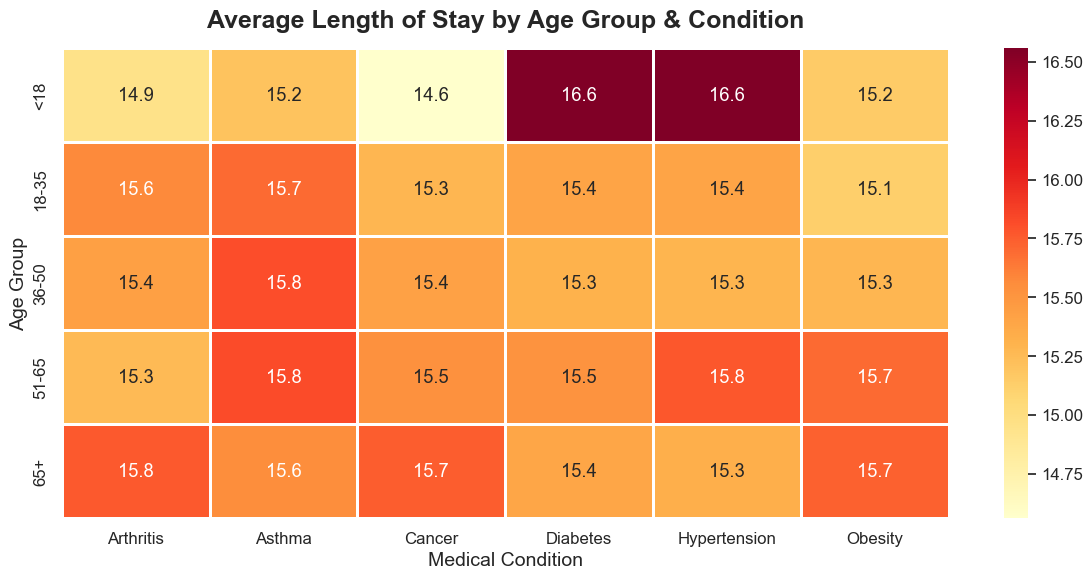

In [26]:
# Age Group vs Medical Condition Heatmap
heatmap_data = df.groupby(['age_group', 'medical_condition'])['len_of_stay'].mean().unstack()

fig, ax = plt.subplots(figsize=(12, 6))

sns.heatmap(
    heatmap_data,
    annot = True,
    fmt = ".1f",
    cmap = 'YlOrRd',
    linewidths = 0.8,
    ax = ax
)

ax.set_title("Average Length of Stay by Age Group & Condition", fontsize=18, fontweight="bold", pad=15)
ax.set_xlabel("Medical Condition", fontsize=14)
ax.set_ylabel("Age Group", fontsize=14)

plt.tight_layout()
plt.savefig("../outputs/figures/06_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()